# Assignment 2

## Problem 1

### Implement Gillespies algorithm

In [5]:
# Import libraries:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


In [2]:
# Define initial values, events and rates

# Initial population
N0 = 1000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Initial time
t = 0

# Step 1: Define events
events = [
    "birth",
    "transmission",
    "recovery",
    "death_X",
    "death_Y",
    "death_Z"
]

# Simulation time
t_max = 365  # 10 years

# Store the state after each event
times = [t]
X_values = [X]
Y_values = [Y]
Z_values = [Z]

In [3]:

while t < t_max:
    
    # Step 2: Calculate rates
    N = X + Y + Z

    rate_birth = mu * N
    rate_transmission = beta * X * Y / N
    rate_recovery = gamma * Y
    rate_death_X = mu * X
    rate_death_Y = mu * Y
    rate_death_Z = mu * Z

    # Step 3: Total rate
    R_total = (
        rate_birth
        + rate_transmission
        + rate_recovery
        + rate_death_X
        + rate_death_Y
        + rate_death_Z
    )

    # Step 4: Waiting time
    RAND_1 = np.random.rand()
    ## Determines when the next event happens

    delta_t = -np.log(RAND_1) / R_total

    # Step 5: Draw random number for event selection
    RAND_2 = np.random.rand()
    ## Determines which event happens next

    # Define P
    P = RAND_2 * R_total

    # Step 6: Select event
    cumulative_rates = np.cumsum([
        rate_birth,
        rate_transmission,
        rate_recovery,
        rate_death_X,
        rate_death_Y,
        rate_death_Z
    ])

    if P <= cumulative_rates[0]:
        event = 0

    elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
        event = 1

    elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
        event = 2

    elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
        event = 3

    elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
        event = 4

    else:
        event = 5

    # Step 7: Update time
    t += delta_t

    # Perform event
    if event == 0:
        X += 1

    elif event == 1:
        X -= 1
        Y += 1

    elif event == 2:
        Y -= 1
        Z += 1

    elif event == 3:
        X -= 1

    elif event == 4:
        Y -= 1

    elif event == 5:
        Z -= 1

    # Store the new state
    times.append(t)
    X_values.append(X)
    Y_values.append(Y)
    Z_values.append(Z)



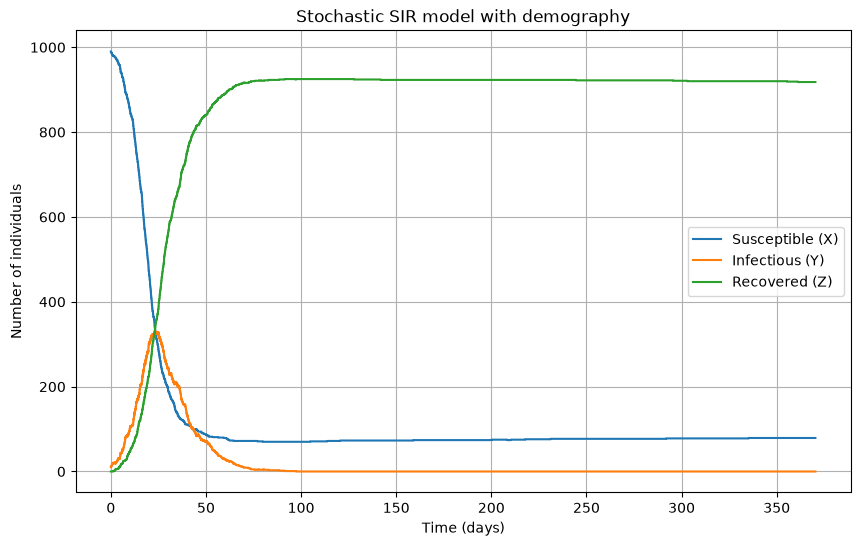

In [4]:
# Plot the Gillespie algorithm:

plt.figure(figsize=(10, 6))

plt.step(times, X_values, label="Susceptible (X)")
plt.step(times, Y_values, label="Infectious (Y)")
plt.step(times, Z_values, label="Recovered (Z)")

plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model with demography")
plt.legend()
plt.grid()

plt.show()

### Compare the GA Stochastic Simulation with an Equivalent Deterministic ODE Model

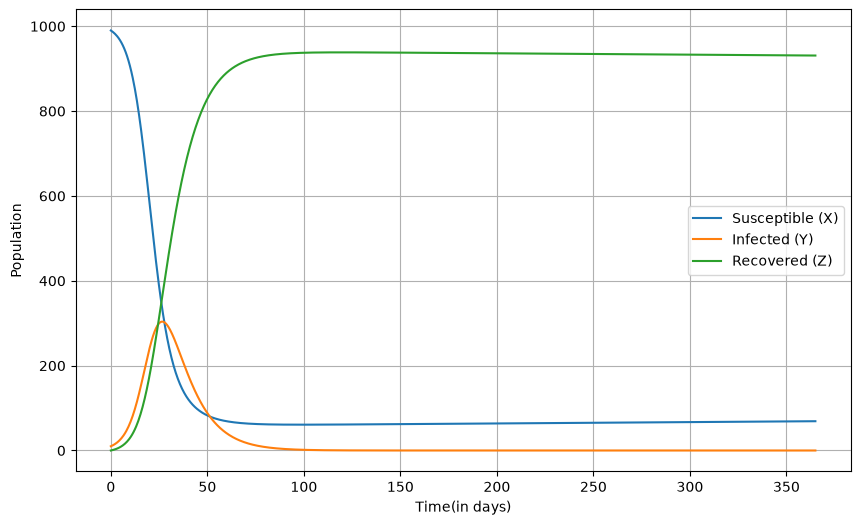

In [ ]:
# Using the same initial values, events and rates

# Initial population
N0 = 1000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z
y0 = [X, Y, Z]

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Time - 1 year 
t = np.linspace(0,365,1000)


def model(y, t, beta, gamma, u):
    s, i, r = y
    N = s + i + r
    dsdt = u*N - beta*s*i/N - u*s
    didt = beta*s*i/N - gamma*i - u*i
    drdt = gamma*i - u*r
    return [dsdt, didt, drdt]

# Numerically integrate the ODE
solution = odeint(model, y0, t, args=(beta, gamma, mu))

s, i, r = solution.T

plt.figure(figsize=(10, 6))
plt.plot(t, s, label="Susceptible (X)")
plt.plot(t, i, label="Infected (Y)")
plt.plot(t, r, label="Recovered (Z)")
plt.xlabel("Time (in days)")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

Both graphs have the same overall shape, with small differences that come from chance from the stochastic model since it shows one possible version of the epidemic, while the ODE describes the average.